# 1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score
from scipy.stats import expon, norm
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
class IPGSReliabilityModel:
    def __init__(self, power_system_size=14, gas_system_size=10):
        """Initialize the integrated power-gas system model with parameters from the paper"""
        self.power_buses = power_system_size
        self.power_lines = 20
        self.generators = 3  # Conventional generators
        self.gas_nodes = gas_system_size
        self.gas_pipes = 6
        self.gas_wells = 2
        self.gas_generators = 2  # Gas-fired generators
        self.power_to_gas = 1  # P2G devices

        # Component parameters with realistic failure rates and impacts
        self.component_params = {
            'power_bus': {'lambda_range': (0.001, 0.05), 'mu': 0.1, 'count': self.power_buses, 'impact': 0.05},
            'power_line': {'lambda_range': (0.002, 0.05), 'mu': 0.15, 'count': self.power_lines, 'impact': 0.08},
            'generator': {'lambda_range': (0.0005, 0.05), 'mu': 0.2, 'count': self.generators, 'impact': 0.25},
            'gas_node': {'lambda_range': (0.001, 0.05), 'mu': 0.1, 'count': self.gas_nodes, 'impact': 0.03},
            'gas_pipe': {'lambda_range': (0.002, 0.05), 'mu': 0.15, 'count': self.gas_pipes, 'impact': 0.12},
            'gas_well': {'lambda_range': (0.0005, 0.05), 'mu': 0.25, 'count': self.gas_wells, 'impact': 0.4},
            'gas_generator': {'lambda_range': (0.001, 0.05), 'mu': 0.15, 'count': self.gas_generators, 'impact': 0.3},
            'power_to_gas': {'lambda_range': (0.001, 0.05), 'mu': 0.15, 'count': self.power_to_gas, 'impact': 0.15}
        }

        # System parameters from the paper
        self.base_power_load = 259  # MW
        self.base_gas_load = 100  # Unitless
        self.ghv = 0.01035  # Gas heating value (MWh/m^3)

        # Critical components identified in the paper
        self.critical_components = {
            'power': ['generator_0', 'generator_1', 'power_line_5', 'power_line_13', 'power_line_8'],
            'gas': ['gas_well_0', 'gas_pipe_0', 'gas_pipe_1', 'gas_pipe_4', 'gas_generator_0']
        }

    def generate_component_failure_rates(self, n_samples):
        """Generate correlated failure rates for all components"""
        components = []
        for comp_type, params in self.component_params.items():
            components.extend([f"{comp_type}_{i}" for i in range(params['count'])])

        # Base rates with some correlation
        base_rates = np.random.uniform(0.001, 0.05, size=(n_samples, len(components)))

        # Add system-wide correlation effect
        system_effect = np.random.uniform(0.8, 1.2, size=n_samples)[:, np.newaxis]
        correlated_rates = base_rates * system_effect

        # Apply component-specific bounds
        data = []
        for i in range(n_samples):
            sample = {}
            for j, col in enumerate(components):
                comp_type = '_'.join(col.split('_')[:-1])
                params = self.component_params[comp_type]
                sample[col] = np.clip(correlated_rates[i,j], *params['lambda_range'])
            data.append(sample)

        return pd.DataFrame(data)

    def sequential_mcs(self, failure_rates, time_horizons=8760, max_iterations=1000, cov_limit=0.05):
        """Enhanced sequential Monte Carlo simulation with progress tracking"""
        results = []
        eegns_history = []
        n_samples = len(failure_rates)
        max_iterations = min(n_samples, max_iterations or n_samples)

        print(f"\nRunning Sequential MCS for {max_iterations} iterations...")
        start_time = time.time()

        for iteration in tqdm(range(max_iterations), desc="MCS Progress"):
            component_states = {}
            for col in failure_rates.columns:
                comp_type = '_'.join(col.split('_')[:-1])
                lambda_q = failure_rates[col].iloc[iteration % n_samples]
                mu_q = self.component_params[comp_type]['mu']

                # Generate realistic failure and repair times with some variability
                ttf = max(0.1, expon.rvs(scale=1/lambda_q) * norm.rvs(loc=1.0, scale=0.1))
                ttr = max(0.1, expon.rvs(scale=1/mu_q) * norm.rvs(loc=1.0, scale=0.15))

                component_states[col] = {
                    'TTF': ttf,
                    'TTR': ttr,
                    'type': comp_type,
                    'impact': self.component_params[comp_type]['impact']
                }

            # Analyze system state at discrete time steps
            time_steps = np.linspace(0, time_horizons, 365)  # Daily samples for a year
            power_shed = self._calculate_load_shedding(component_states, time_steps, system='power')
            gas_shed = self._calculate_load_shedding(component_states, time_steps, system='gas')

            # Calculate reliability metrics
            eens = np.sum(power_shed) * (8760 / len(time_steps))  # Convert to annual
            egns = np.sum(gas_shed) * (8760 / len(time_steps)) * self.ghv
            eegns = eens + egns

            results.append({
                'EENS': eens,
                'EGNS': egns,
                'EEGNS': eegns,
                **{k:v for k,v in failure_rates.iloc[iteration % n_samples].items()}
            })
            eegns_history.append(eegns)

            # Check for convergence
            if len(eegns_history) > 100:
                current_cov = np.std(eegns_history) / np.mean(eegns_history)
                if current_cov <= cov_limit:
                    print(f"\nConverged at {iteration+1} iterations (COV={current_cov:.4f})")
                    break

        total_time = time.time() - start_time
        print(f"MCS completed in {total_time:.2f} seconds")
        return pd.DataFrame(results)

    def _calculate_load_shedding(self, component_states, time_steps, system='power'):
        """Calculate load shedding considering cascading effects"""
        base_load = self.base_power_load if system == 'power' else self.base_gas_load
        shedding = np.zeros(len(time_steps))
        critical_comps = [c for c in self.critical_components[system] if c in component_states]

        for i, t in enumerate(time_steps):
            total_impact = 0
            n_failed = 0

            for comp in critical_comps:
                state = component_states[comp]
                if state['TTF'] < t < (state['TTF'] + state['TTR']):
                    # Cascading effect: more failures increase impact
                    cascading_factor = 1 + (n_failed * 0.1)
                    total_impact += state['impact'] * cascading_factor
                    n_failed += 1

            if n_failed > 0:
                # Non-linear relationship between failures and load shedding
                shedding[i] = base_load * (1 - np.exp(-total_impact * (1 + np.log1p(n_failed))))

            # Add realistic noise
            shedding[i] *= norm.rvs(loc=1.0, scale=0.03)
            shedding[i] = np.clip(shedding[i], 0, base_load)

        return shedding

    def train_model(self, data, target_metric='EEGNS', max_features=40, cv_folds=5):
        """Enhanced training pipeline with feature selection and XGBoost"""
        X = data.drop(['EENS', 'EGNS', 'EEGNS'], axis=1)
        y = data[target_metric]

        # Split data for validation
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42)

        print("\nStarting model training process...")
        print(f"Original feature count: {X.shape[1]}")

        # Step 1: Find optimal number of features using RFE with Random Forest
        print("\nFinding optimal number of features...")
        feature_counts = np.linspace(5, min(max_features, X.shape[1]), 8, dtype=int)
        best_score = -np.inf
        best_n = 5
        feature_results = []

        for n in tqdm(feature_counts, desc="Feature Selection"):
            rfe = RFE(
                estimator=RandomForestRegressor(n_estimators=200, random_state=42),
                n_features_to_select=n,
                step=0.1
            )

            # Simple pipeline for feature selection evaluation
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('selector', rfe),
                ('model', XGBRegressor(n_estimators=100, random_state=42))
            ])

            score = cross_val_score(pipe, X_train, y_train, cv=cv_folds, scoring='r2').mean()
            feature_results.append((n, score))

            if score > best_score:
                best_score = score
                best_n = n
            tqdm.write(f"Testing {n} features: R²={score:.4f} (Best: {best_score:.4f} with {best_n} features)")

        # Step 2: Train final model with optimal features
        print(f"\nTraining final model with {best_n} features...")
        final_rfe = RFE(
            estimator=RandomForestRegressor(n_estimators=300, random_state=42),
            n_features_to_select=best_n,
            step=0.1
        )

        # Enhanced XGBoost model with target transformation
        final_model = TransformedTargetRegressor(
            regressor=XGBRegressor(
                n_estimators=1000,
                learning_rate=0.01,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                gamma=0.1,
                reg_alpha=0.5,
                reg_lambda=1.0,
                random_state=42
            ),
            transformer=PowerTransformer(method='yeo-johnson')
        )

        final_pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('selector', final_rfe),
            ('model', final_model)
        ])

        # Cross-validation
        print("\nRunning cross-validation...")
        cv_scores = cross_val_score(final_pipe, X_train, y_train, cv=cv_folds, scoring='r2')

        # Fit final model
        print("\nTraining final XGBoost model...")
        final_pipe.fit(X_train, y_train)

        # Get selected features
        selected_features = X.columns[final_rfe.support_]

        # Feature importance
        xgb_model = final_pipe.named_steps['model'].regressor_
        importance = pd.DataFrame({
            'Feature': selected_features,
            'Importance': xgb_model.feature_importances_
        }).sort_values('Importance', ascending=False)

        # Evaluation
        train_score = final_pipe.score(X_train, y_train)
        test_score = final_pipe.score(X_test, y_test)
        mean_cv_score = np.mean(cv_scores)

        print("\n=== Training Results ===")
        print(f"Optimal features: {best_n}")
        print(f"Training R²: {train_score:.4f}")
        print(f"Test R²: {test_score:.4f}")
        print(f"Cross-validated R²: {mean_cv_score:.4f} ± {np.std(cv_scores):.4f}")

        return {
            'model': final_pipe,
            'feature_importance': importance,
            'selected_features': selected_features,
            'cv_scores': cv_scores,
            'train_score': train_score,
            'test_score': test_score,
            'optimal_features': best_n
        }

In [ ]:
def run_simulation():
    # Initialize the model
    ipgs = IPGSReliabilityModel()

    # Generate failure rates (1000 samples for demonstration)
    print("Generating component failure rates...")
    failure_rates = ipgs.generate_component_failure_rates(1000)

    # Run sequential MCS
    results = ipgs.sequential_mcs(
        failure_rates=failure_rates,
        time_horizons=8760,  # 1 year in hours
        max_iterations=1500,   # Reduced for demonstration
        cov_limit=0.05
    )

    # Train machine learning model
    ml_results = ipgs.train_model(results, target_metric='EEGNS', max_features=40)

    return ipgs, failure_rates, results, ml_results

# Run the complete simulation
ipgs, failure_rates, mcs_results, ml_results = run_simulation()

Generating component failure rates...

Running Sequential MCS for 500 iterations...


MCS Progress: 100%|██████████| 500/500 [00:22<00:00, 22.22it/s]


MCS completed in 22.51 seconds

Starting model training process...
Original feature count: 58

Finding optimal number of features...


Feature Selection:  12%|█▎        | 1/8 [01:20<09:20, 80.06s/it]

Testing 5 features: R²=-0.3579 (Best: -0.3579 with 5 features)


...

Testing 30 features: R²=-0.2711 (Best: -0.2711 with 30 features)


Feature Selection:  88%|████████▊ | 7/8 [08:21<01:06, 66.53s/it]

Testing 35 features: R²=-0.3189 (Best: -0.2711 with 30 features)


Feature Selection: 100%|██████████| 8/8 [09:13<00:00, 69.14s/it]


Testing 40 features: R²=-0.2848 (Best: -0.2711 with 30 features)

Training final model with 30 features...

Running cross-validation...

Training final XGBoost model...

=== Training Results ===
Optimal features: 30
Training R²: 0.8842
Test R²: -0.4347
Cross-validated R²: -0.4228 ± 0.0919


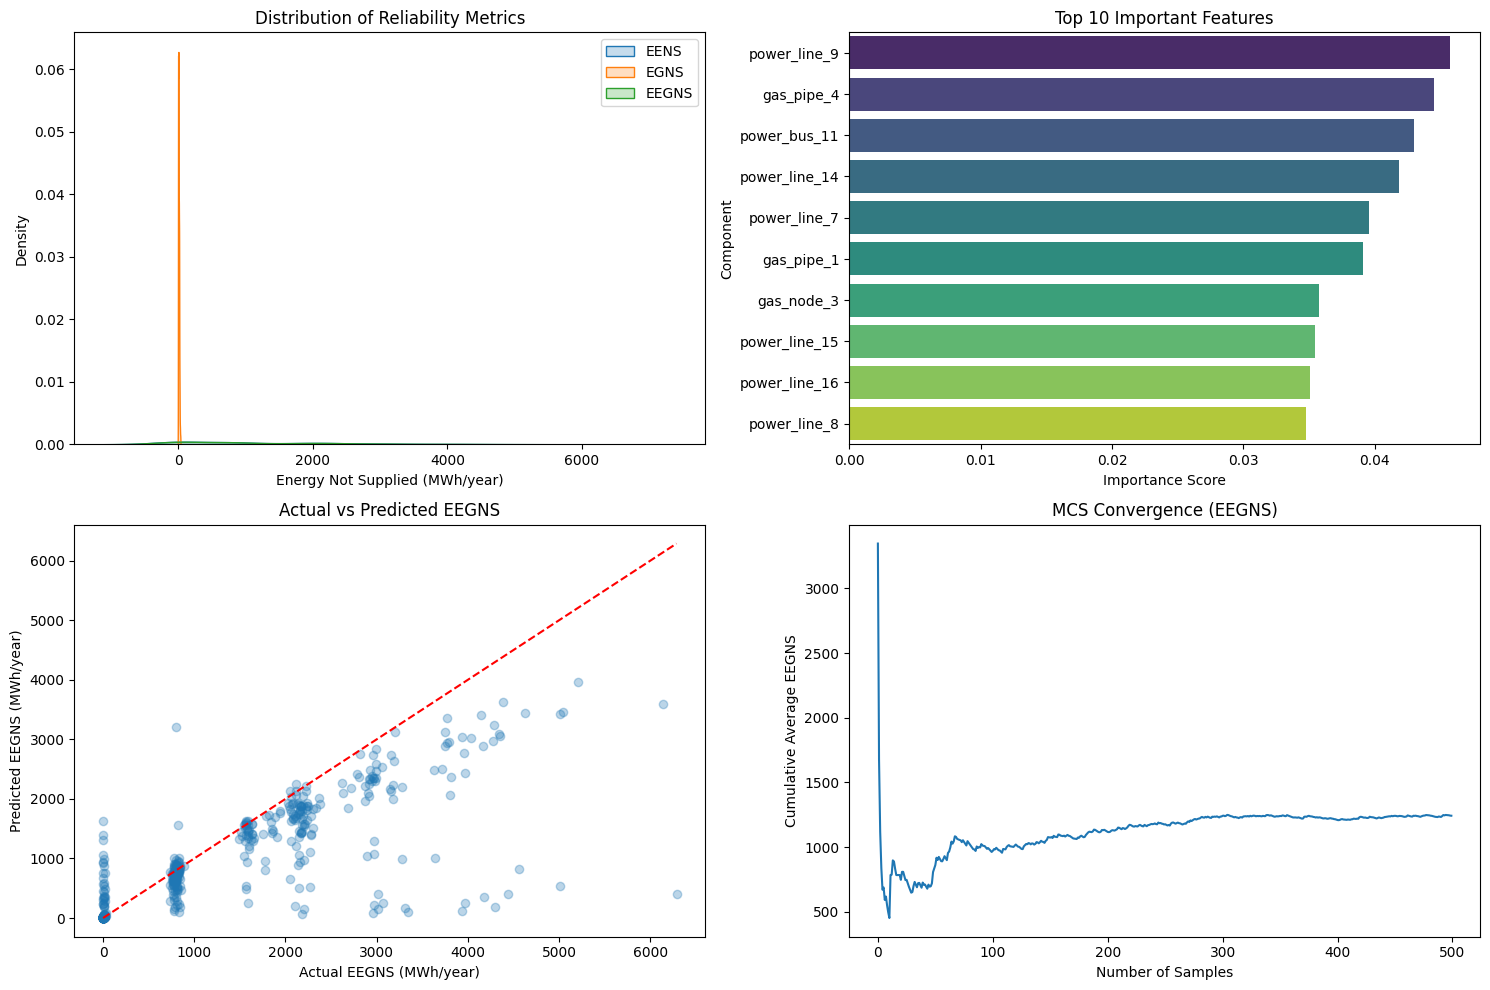

In [ ]:
def plot_results(ipgs, failure_rates, mcs_results, ml_results):
    """Visualize the simulation results"""
    plt.figure(figsize=(15, 10))

    # Plot 1: Distribution of reliability metrics
    plt.subplot(2, 2, 1)
    sns.kdeplot(mcs_results['EENS'], label='EENS', fill=True)
    sns.kdeplot(mcs_results['EGNS'], label='EGNS', fill=True)
    sns.kdeplot(mcs_results['EEGNS'], label='EEGNS', fill=True)
    plt.title('Distribution of Reliability Metrics')
    plt.xlabel('Energy Not Supplied (MWh/year)')
    plt.ylabel('Density')
    plt.legend()

    # Plot 2: Feature importance
    plt.subplot(2, 2, 2)
    top_features = ml_results['feature_importance'].head(10)
    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title('Top 10 Important Features')
    plt.xlabel('Importance Score')
    plt.ylabel('Component')

    # Plot 3: Actual vs Predicted values
    plt.subplot(2, 2, 3)
    X = mcs_results.drop(['EENS', 'EGNS', 'EEGNS'], axis=1)
    y = mcs_results['EEGNS']
    predictions = ml_results['model'].predict(X)
    plt.scatter(y, predictions, alpha=0.3)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.title('Actual vs Predicted EEGNS')
    plt.xlabel('Actual EEGNS (MWh/year)')
    plt.ylabel('Predicted EEGNS (MWh/year)')

    # Plot 4: Convergence of MCS
    plt.subplot(2, 2, 4)
    plt.plot(np.cumsum(mcs_results['EEGNS']) / np.arange(1, len(mcs_results)+1))
    plt.title('MCS Convergence (EEGNS)')
    plt.xlabel('Number of Samples')
    plt.ylabel('Cumulative Average EEGNS')

    plt.tight_layout()
    plt.show()

# Generate visualizations
plot_results(ipgs, failure_rates, mcs_results, ml_results)

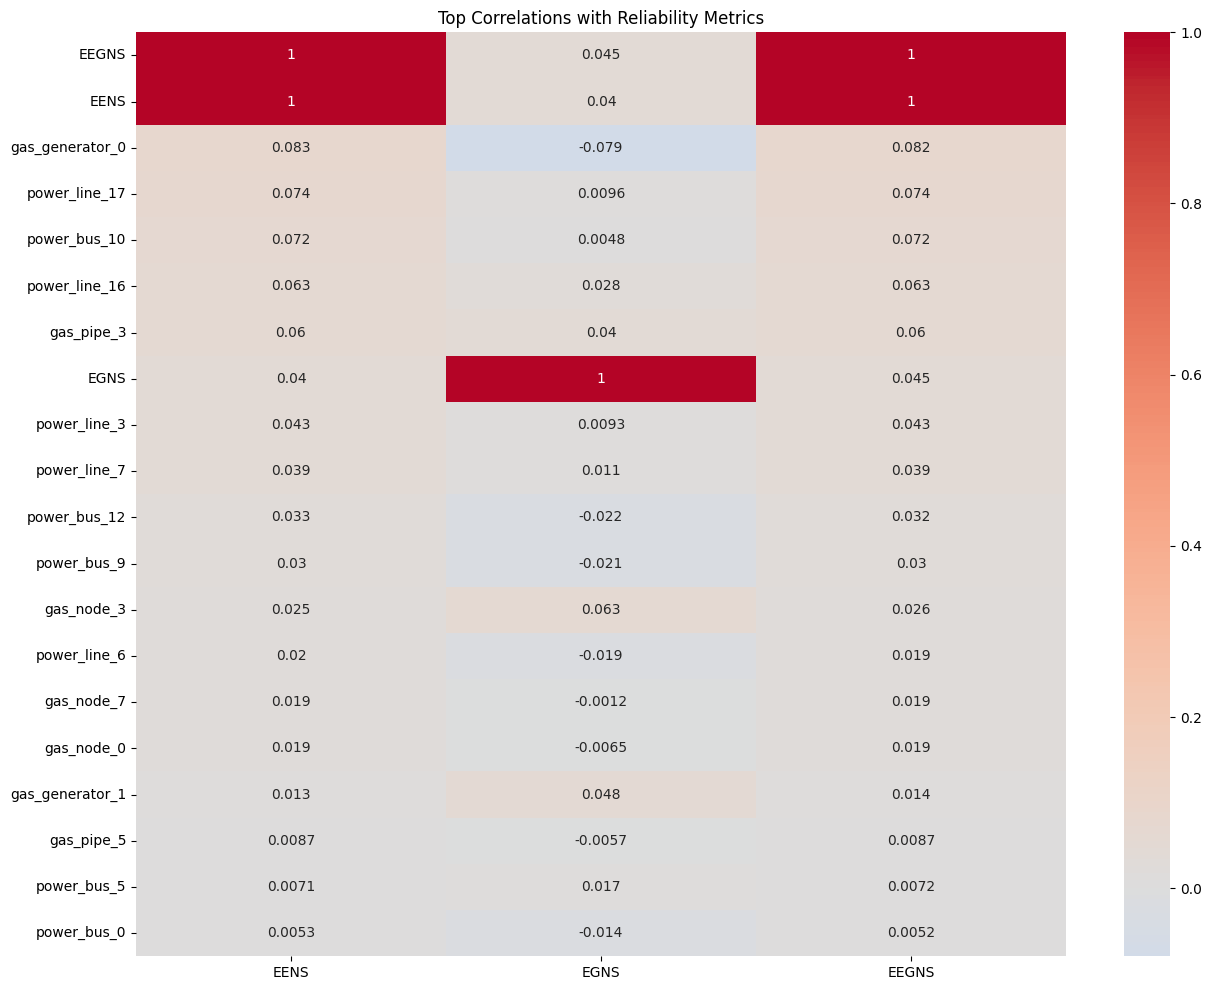

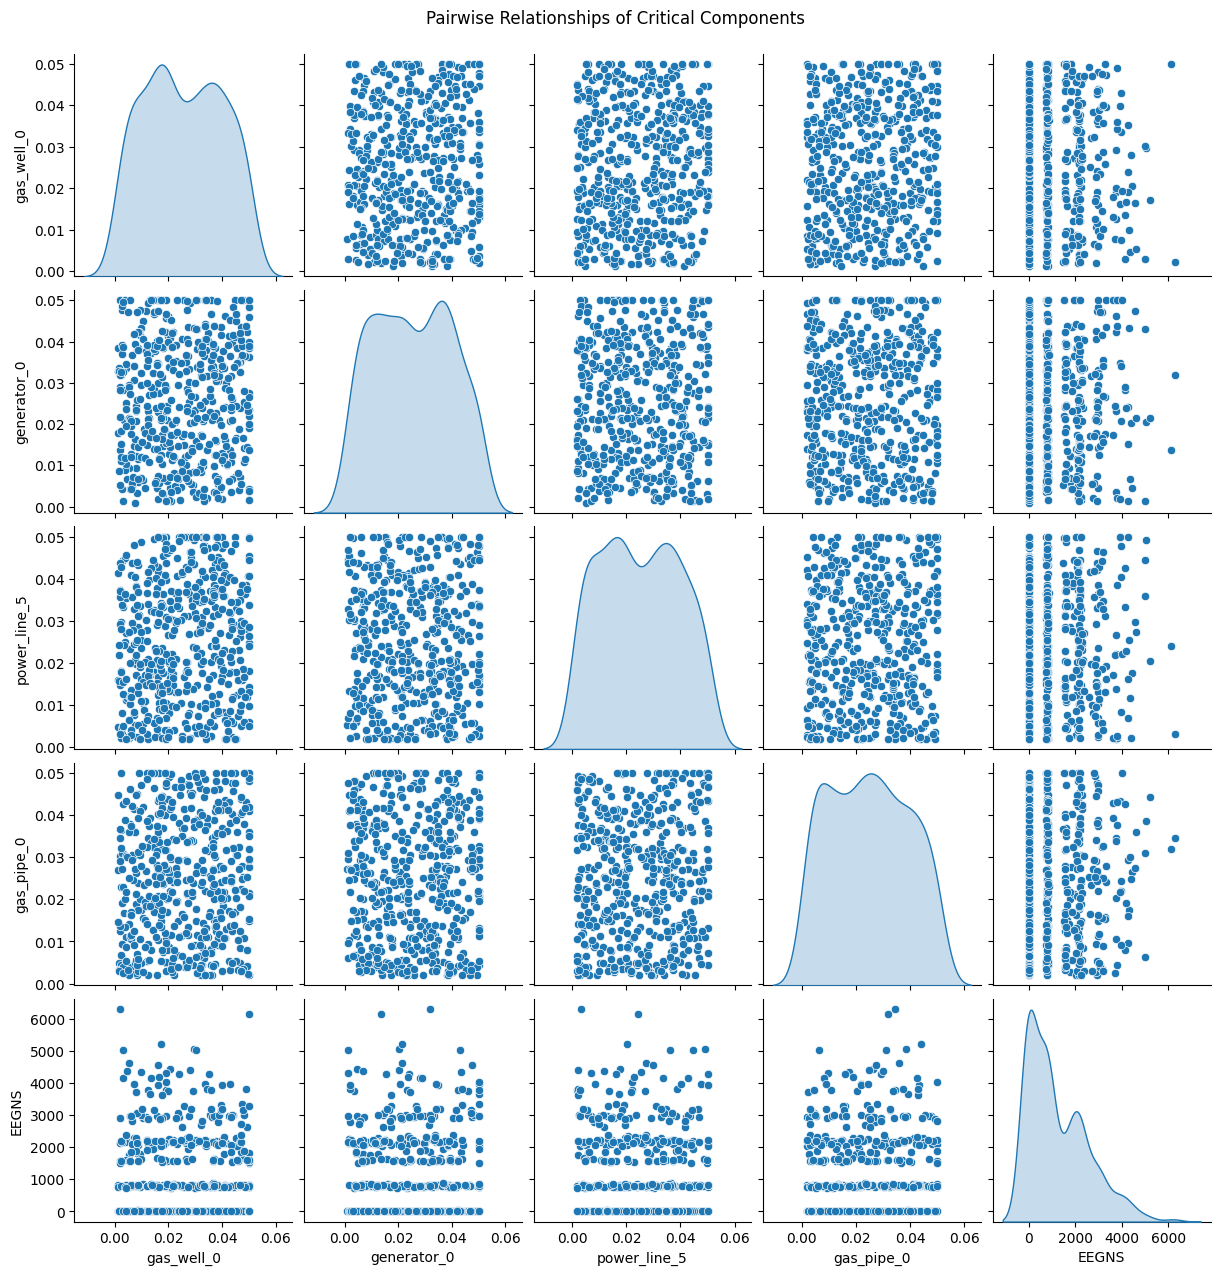

In [ ]:
def additional_analysis(mcs_results):
    """Perform additional analysis on the results"""
    # Correlation between component failures and reliability metrics
    corr_matrix = mcs_results.corr()

    # Plot correlation heatmap
    plt.figure(figsize=(15, 12))
    sns.heatmap(corr_matrix[['EENS', 'EGNS', 'EEGNS']].sort_values('EEGNS', ascending=False).head(20),
                annot=True, cmap='coolwarm', center=0)
    plt.title('Top Correlations with Reliability Metrics')
    plt.show()

    # Pairplot of selected components vs EEGNS
    selected_components = ['gas_well_0', 'generator_0', 'power_line_5', 'gas_pipe_0', 'EEGNS']
    sns.pairplot(mcs_results[selected_components], diag_kind='kde')
    plt.suptitle('Pairwise Relationships of Critical Components', y=1.02)
    plt.show()

# Run additional analysis
additional_analysis(mcs_results)